# Signal Segmentation with PELT

**PELT (Pruned Exact Linear Time)** is an exact changepoint detection algorithm.  
It minimises a penalised cost function and runs in **O(n)** time on average,  
making it suitable for long timeseries.

Here we:
1. Load synthetic multi-variable timeseries from a CSV file using **pandas**.
2. Apply PELT independently on each variable via the **ruptures** library.
3. Visualise the raw signal and the detected changepoints.

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ruptures as rpt          # PELT changepoint detection

In [2]:
# ── 1. Load data ──────────────────────────────────────────────────────────────
# pandas reads the CSV; parse_dates converts the timestamp column to datetime objects
df = pd.read_csv("timeseries_data.csv", parse_dates=["timestamp"])
df = df.set_index("timestamp")   # use time as the DataFrame index for nicer plots

print(f"Shape  : {df.shape}")
print(f"Period : {df.index[0]}  →  {df.index[-1]}")
df.describe().round(3)

Shape  : (500, 3)
Period : 2024-01-01 00:00:00  →  2024-01-21 19:00:00


,temperature_C,pressure_hPa,vibration_mm_s
count,500.000,500.000,500.000
mean,23.260,1010.846,1.069
std,4.664,6.692,0.687
min,14.150,997.055,-0.248
25%,19.240,1005.830,0.558
50%,23.443,1009.435,0.871
75%,27.006,1016.109,1.620
max,33.897,1029.537,2.927


In [3]:
# ── 2. PELT changepoint detection ─────────────────────────────────────────────
#
# ruptures.Pelt parameters:
#   model = "rbf"  → Radial Basis Function cost; detects shifts in mean AND variance.
#                    Other options: "l1" (median), "l2" (mean only), "cosine".
#   pen            → penalty value; higher = fewer changepoints.
#                    Heuristic: pen ≈ log(n) × σ²  (tune per variable noise level)
#
# algo.predict() returns a list of segment-END indices (1-indexed).
# The final value is always n (end of signal) so we drop it before plotting.

def detect_changepoints(series: pd.Series, pen: float = 10) -> list[int]:
    """
    Apply PELT on a univariate pandas Series and return changepoint indices.

    Parameters
    ----------
    series : pd.Series  – 1-D signal (no NaNs)
    pen    : float      – penalty that controls the number of changepoints

    Returns
    -------
    list[int]  – 0-based indices where a regime change is detected
    """
    signal = series.to_numpy()           # ruptures works on plain numpy arrays
    algo = rpt.Pelt(model="rbf").fit(signal)
    result = algo.predict(pen=pen)       # list of end positions (1-indexed)
    return [idx - 1 for idx in result[:-1]]   # drop last (= n), convert to 0-based


# Penalty tuned per variable: noisier signal → higher penalty needed
penalty_map = {
    "temperature_C":  15,
    "pressure_hPa":   50,
    "vibration_mm_s":  5,
}

changepoints = {}
for col, pen in penalty_map.items():
    cps = detect_changepoints(df[col], pen=pen)
    changepoints[col] = cps
    print(f"{col:25s}  pen={pen:4}  → {len(cps)} changepoints at indices: {cps}")

temperature_C              pen=  15  → 3 changepoints at indices: [119, 279, 399]
pressure_hPa               pen=  50  → 2 changepoints at indices: [249, 369]
vibration_mm_s             pen=   5  → 2 changepoints at indices: [149, 299]


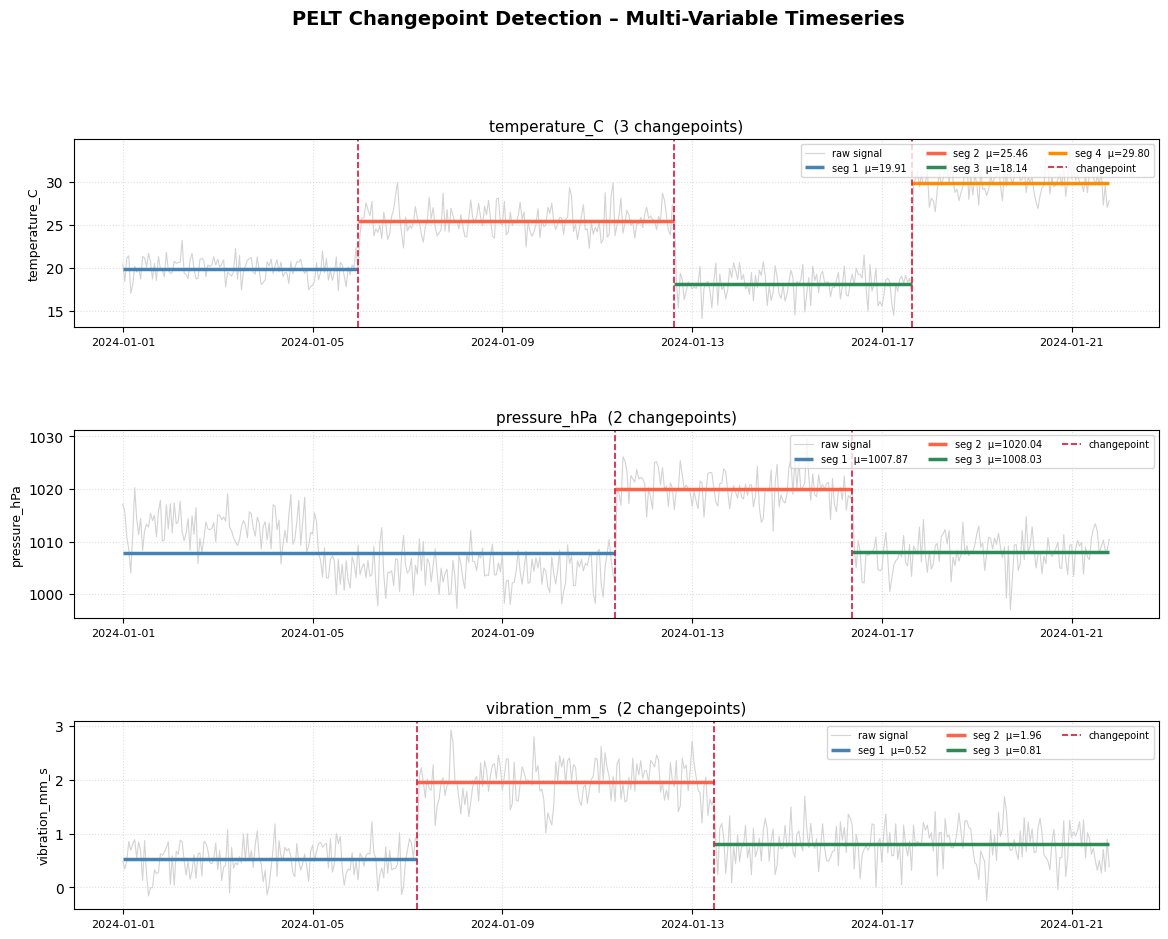

Figure saved → pelt_segmentation.png


In [4]:
# ── 3. Visualisation ──────────────────────────────────────────────────────────
#
# Layout: one subplot per variable.
#   · Light grey line     → raw signal
#   · Coloured h-lines    → per-segment mean (one colour per segment)
#   · Red dashed v-lines  → detected changepoints

COLORS   = ["steelblue", "tomato", "seagreen", "darkorange"]
CP_COLOR = "crimson"
time_axis = df.index

fig = plt.figure(figsize=(14, 10))
fig.suptitle("PELT Changepoint Detection – Multi-Variable Timeseries",
             fontsize=14, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(len(df.columns), 1, hspace=0.55)

for ax_idx, col in enumerate(df.columns):
    ax     = fig.add_subplot(gs[ax_idx])
    signal = df[col].to_numpy()
    cps    = changepoints[col]

    # Raw signal (thin, faded so segment means stand out)
    ax.plot(time_axis, signal, color="lightgrey", linewidth=0.8, label="raw signal")

    # Build segment boundaries: [0, cp1, cp2, ..., n-1]
    boundaries = [0] + cps + [len(signal) - 1]
    for seg_idx in range(len(boundaries) - 1):
        start, end = boundaries[seg_idx], boundaries[seg_idx + 1]
        seg_mean   = signal[start : end + 1].mean()
        color      = COLORS[seg_idx % len(COLORS)]
        # Horizontal line spanning the segment at the regime mean
        ax.hlines(seg_mean, time_axis[start], time_axis[end],
                  colors=color, linewidth=2.5,
                  label=f"seg {seg_idx + 1}  μ={seg_mean:.2f}")

    # Vertical dashed lines at each changepoint
    for cp_idx, cp in enumerate(cps):
        ax.axvline(time_axis[cp], color=CP_COLOR, linestyle="--", linewidth=1.2,
                   label="changepoint" if cp_idx == 0 else None)

    ax.set_title(f"{col}  ({len(cps)} changepoint{'s' if len(cps) != 1 else ''})",
                 fontsize=11)
    ax.set_ylabel(col, fontsize=9)
    ax.legend(fontsize=7, loc="upper right", ncol=3)
    ax.grid(True, linestyle=":", alpha=0.4)
    ax.tick_params(axis="x", labelsize=8)

plt.savefig("pelt_segmentation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → pelt_segmentation.png")